# Dataset

source: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

Ten baseline variables:
- age
- sex
- body mass index
- average blood pressure, and 
- six blood serum measurements, for each of 442 diabetes patients.

The response of interest: 
- A quantitative measure of disease progression one year after baseline.

In [1]:
# importing the scikit-learn library
from sklearn.datasets import load_diabetes
# importing numpy
import numpy as np

# loading diabetes dataset
diabetes = load_diabetes()
X = diabetes.data # extracting input features
Y = diabetes.target # extracting targets
features = diabetes.feature_names # extracting feature names

In [2]:
# importing pandas library
import pandas as pd

# Loading the numpy arrays into a dataframe
df = pd.DataFrame(X, columns=features)

In [3]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


# Deep Learning

The word Deep Learning signifies that our Neural Network architecture is deep, i.e. there are multiple instances of each operation (specifically Matrix Multiplication and Bias Addition, as they make up a layer). These operations are applied in specific order such that they map input features to labels.

Extracting one example (very first row) from the dataset for the sake of simplicity.

In [4]:
# Extracting the first example
X0 = X[0].reshape(1, 10)
X0, X0.shape

(array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187235, -0.0442235 ,
         -0.03482076, -0.04340085, -0.00259226,  0.01990842, -0.01764613]]),
 (1, 10))

**Matrix Multiplication**

Defining the `MatMul` function.

In [5]:
def matMul(inp_: np.ndarray, W: np.ndarray):
  '''
  Performs Matrix Multiplication
  '''
  return np.dot(inp_, W)

Randomly initializing the weights $W_1$.

In [6]:
import numpy as np
np.random.seed(0)
W1 = np.random.rand(10,6)*0.01
W1, W1.shape

(array([[0.00548814, 0.00715189, 0.00602763, 0.00544883, 0.00423655,
         0.00645894],
        [0.00437587, 0.00891773, 0.00963663, 0.00383442, 0.00791725,
         0.00528895],
        [0.00568045, 0.00925597, 0.00071036, 0.00087129, 0.00020218,
         0.0083262 ],
        [0.00778157, 0.00870012, 0.00978618, 0.00799159, 0.00461479,
         0.00780529],
        [0.00118274, 0.00639921, 0.00143353, 0.00944669, 0.00521848,
         0.00414662],
        [0.00264556, 0.00774234, 0.0045615 , 0.00568434, 0.0001879 ,
         0.00617635],
        [0.00612096, 0.00616934, 0.00943748, 0.0068182 , 0.00359508,
         0.00437032],
        [0.00697631, 0.00060225, 0.00666767, 0.00670638, 0.00210383,
         0.00128926],
        [0.00315428, 0.00363711, 0.00570197, 0.00438602, 0.00988374,
         0.00102045],
        [0.00208877, 0.0016131 , 0.00653108, 0.00253292, 0.00466311,
         0.00244426]]), (10, 6))

Performing *Matrix Multiplication*.

In [7]:
H1 = matMul(X0, W1)
H1, H1.shape

(array([[ 0.00054917,  0.00070766,  0.00032493, -0.00025603,  0.00039165,
          0.00058411]]), (1, 6))

**Bias Addition**

Defining `biasAdd` function.

In [8]:
def biasAdd(B: np.ndarray, inp_: np.ndarray):
  '''
  Performs Bias Addition
  '''
  return inp_ + B

Initialising bias $b_1$.

In [9]:
B1 = np.zeros((1, 6))
B1, B1.shape

(array([[0., 0., 0., 0., 0., 0.]]), (1, 6))

Performing *Bias Addition*.

In [10]:
Z1 = biasAdd(B1, H1)
Z1, Z1.shape

(array([[ 0.00054917,  0.00070766,  0.00032493, -0.00025603,  0.00039165,
          0.00058411]]), (1, 6))

**Activation**

Defining *Sigmoid Activation* function and applying it to $Z_1$.

In [11]:
def sigmoid(Z):
  return 1/(1+np.exp(-Z))

In [12]:
A1 = sigmoid(Z1)
A1, A1.shape

(array([[0.50013729, 0.50017691, 0.50008123, 0.49993599, 0.50009791,
         0.50014603]]), (1, 6))

Defining *Linear Activation*

In [13]:
def linear(Z):
    return Z

# **Forward Pass**

Completing the Neural Network by defining the remaining operations.

In [14]:
def init_weights(numX0, numH1, numH2):
    '''
    Initializing Parameters for the NN
		
		numX0: number of features in input dataset
		numH1: number of nodes in hidden layer
		numH2: number of nodes in output layer
    '''
    # defining weights and biases
    np.random.seed(0)
    W1 = np.random.rand(numX0,numH1)*0.01
    B1 = np.zeros((1, numH1))

    np.random.seed(1)
    W2 = np.random.rand(numH1, numH2)*0.01
    B2 = np.zeros((1, numH2))

    params = [W1, B1, W2, B2]
    return params

In [15]:
def forward(inp_: np.ndarray,
            params: list):
    '''
    Forward pass through a Neural Network
    '''
    W1, B1, W2, B2 = params

    # Forward Pass
    H1 = matMul(inp_, W1)
    Z1 = biasAdd(B1, H1)
    A1 = sigmoid(Z1)

    H2 = matMul(A1, W2)
    Z2 = biasAdd(B2, H2)
    A2 = linear(Z2)

    cache = (H1, Z1, A1, H2, Z2)
    return A2, cache

In [16]:
params = init_weights(X0.shape[1], 6, 1)
Yhat, cache = forward(X0, params)
Yhat, Yhat.shape

(array([[0.00839637]]), (1, 1))

# Training

Extracting labels corresponding to the first example.

In [17]:
Y0 = Y[0].reshape(1,1)
Y0, Y0.shape

(array([[151.]]), (1, 1))

**Mean Squared Error**

Defining the *Mean Squared Error* loss function.

In [18]:
def MSE(y, yHat):
    n = y.shape[0]
    return 1/n*np.sum(np.square(y-yHat), axis=0)

In [19]:
lossVal1 = MSE(Y0, Yhat)
lossVal1, lossVal1.shape

(array([22798.46436626]), (1,))

**Grads**

In [20]:
def grad_MSE(y, yHat):
    '''
    Function that computes gradient
    of loss wrt yHat
    '''
    n = y.shape[0]
    return -2/n*(y-yHat)

In [21]:
def grad_linear(outGrad, inp_):
    '''
    Function that computes gradient
    of loss wrt inp_
		
		outGrad: Gradient of Loss wrt Yhat
		inp_: Input to Linear Activation i.e. Z2
    '''
		# Grad of Yhat wrt to Z2 is a matrix of ones
    dinp_ = outGrad * np.ones(inp_.shape) 
    return dinp_

In [22]:
def grad_biasAdd(outGrad, B, inp_):
    '''
    Function that computes gradient
    of loss wrt B and H
    '''
    dB = np.sum(outGrad, axis=0)
    dinp_ = outGrad * np.ones(inp_.shape)
    return np.expand_dims(dB, axis=0), dinp_

In [23]:
def grad_matMul(outGrad, W, inp_):
    '''
    Function that computes gradient
    of loss wrt W and inp_
    '''
    dW = np.dot(inp_.T, outGrad)
    dinp_ = np.dot(outGrad, W.T)
    return dW, dinp_

In [24]:
def grad_sigmoid(outGrad, inp_):
    '''
    Function that computes gradient
    of loss wrt inp_
    '''
    dinp_ = outGrad * sigmoid(inp_)*(1-sigmoid(inp_)) 
    return dinp_

**Backward Pass**

In [25]:
def backward(x, y, yHat, params, cache):
    '''
    Does Backward pass through the Network 
    to compute all the gradients required
    '''
    H1, Z1, A1, H2, Z2 = cache
    W1, B1, W2, B2 = params

    dYhat = grad_MSE(y, yHat)
    
    dZ2 = grad_linear(dYhat, Z2)

    dB2, dH2 = grad_biasAdd(dZ2, B2, H2)
    assert B2.shape == dB2.shape

    dW2, dA1 = grad_matMul(dH2, W2, A1)
    assert W2.shape == dW2.shape

    dZ1 = grad_sigmoid(dA1, Z1)

    dB1, dH1 = grad_biasAdd(dZ1, B1, H1)
    assert B1.shape == dB1.shape

    dW1, _ = grad_matMul(dH1, W1, x)
    assert W1.shape == dW1.shape

    param_grads = (dW1, dB1, dW2, dB2)
    return param_grads

In [26]:
param_grads = backward(X0, Y0, Yhat, params, cache)

**Updating the weights**

In [27]:
def update(params, param_grads, alpha):
    '''
    Updating the Parameters using SGD
    '''
    assert len(params) == len(param_grads)

    for i in range(len(params)):
        params[i] -= alpha*param_grads[i]

    return params

In [28]:
params = update(params, param_grads, 0.01)

Now that we have updated the weights, let's look at the loss now.

In [30]:
Yhat, _ = forward(X0, params)
lossVal2 = MSE(Y0, Yhat)
lossVal2

array([20573.71888798])

Plotting the two values.

Text(0, 0.5, 'Loss Value')

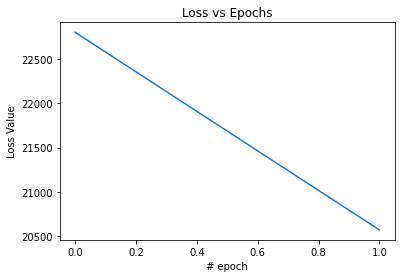

In [31]:
import matplotlib.pyplot as plt

plt.plot([lossVal1 ,lossVal2])
plt.title("Loss vs Epochs")
plt.xlabel("# epoch")
plt.ylabel("Loss Value")